# 01 — Data Understanding & Exploratory Audit
## Hospital Readmission Risk Prediction System (DISCHARGE)
**Dataset:** UCI Diabetes 130-US Hospitals (1999–2008)  
**Roadmap Task:** `P1-06`  
**Purpose:** Explore data structure, column distributions, missing value markers (`?`), encounter multiplicity per patient, and target balance (`readmitted_30d`).

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

from readmission.config import REPO_ROOT, RAW_DIABETIC_DATA_CSV, RAW_IDS_MAPPING_CSV
from readmission.db import get_engine

print(f"Working directory: {REPO_ROOT}")


Working directory: E:\Projects\College Projects\DISCHARGE


### 1. Connecting to PostgreSQL `raw.diabetic_data`
We pull the 101,766 encounters stored in the `raw` schema of our PostgreSQL database.

In [2]:
engine = get_engine()
with engine.connect() as conn:
    df_raw = pd.read_sql("SELECT * FROM raw.diabetic_data", conn)

print(f"Loaded DataFrame shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
df_raw.head(3)


Loaded DataFrame shape: 101,766 rows, 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


### 2. Missing Value Markers (`'?'` vs `NULL` vs `'None'`)
The UCI dataset encodes missing data as `'?'`. Furthermore, in `A1Cresult` and `max_glu_serum`, the string `'None'` indicates *test was not ordered*, which is a clinically informative category and not missing data.

In [3]:
question_mark_counts = (df_raw == '?').sum()
missing_pct = (question_mark_counts / len(df_raw)) * 100
missing_table = pd.DataFrame({
    'Question_Mark_Count': question_mark_counts,
    'Percent_Missing': missing_pct
}).sort_values('Percent_Missing', ascending=False)

print("Top 10 columns by missingness ('?'):")
missing_table.head(10)


Top 10 columns by missingness ('?'):


,Question_Mark_Count,Percent_Missing
weight,98569,96.858479
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
admission_type_id,0,0.000000
patient_nbr,0,0.000000
encounter_id,0,0.000000


### 3. Target Distribution (`readmitted`)
The dataset outcome has three classes:
- `<30`: Readmitted within 30 days (**Primary Target**, 1)
- `>30`: Readmitted after 30 days (0)
- `NO`: No recorded readmission (0)

In [4]:
target_counts = df_raw['readmitted'].value_counts()
target_pct = df_raw['readmitted'].value_counts(normalize=True) * 100

target_df = pd.DataFrame({'Encounters': target_counts, 'Percentage': target_pct.round(2)})
display(target_df)

# Target binary definition
readmit_30d = (df_raw['readmitted'] == '<30').astype(int)
base_rate = readmit_30d.mean() * 100
print(f"\n30-Day Readmission Prevalence (Base Rate): {base_rate:.2f}% ({readmit_30d.sum():,} encounters)")


,Encounters,Percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16



30-Day Readmission Prevalence (Base Rate): 11.16% (11,357 encounters)


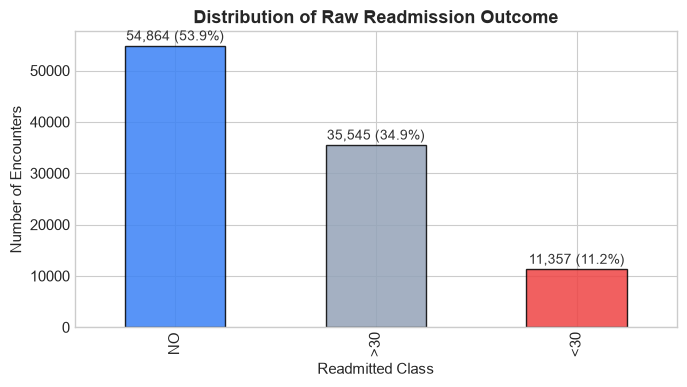

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
target_counts.plot(kind='bar', color=['#3b82f6', '#94a3b8', '#ef4444'], ax=ax, edgecolor='black', alpha=0.85)
ax.set_title("Distribution of Raw Readmission Outcome", fontsize=13, fontweight='bold')
ax.set_ylabel("Number of Encounters")
ax.set_xlabel("Readmitted Class")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,} ({p.get_height()/len(df_raw)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() + 1000),
                ha='center', fontsize=10, color='#333333')
plt.tight_layout()
plt.show()


### 4. Patient Multiplicity & Data Leakage Prevention
Patients in the dataset can have multiple encounters. Splitting by row would leak patient characteristics into the test set. Here we analyze patient encounter frequency.

In [6]:
total_encounters = len(df_raw)
unique_patients = df_raw['patient_nbr'].nunique()
encounters_per_patient = df_raw.groupby('patient_nbr').size()

print(f"Total encounters: {total_encounters:,}")
print(f"Unique patients: {unique_patients:,}")
print(f"Encounters per patient — Mean: {encounters_per_patient.mean():.2f}, Max: {encounters_per_patient.max()}")

counts_freq = encounters_per_patient.value_counts().sort_index()
print("\nEncounter frequency distribution (first 5):")
print(counts_freq.head(5))


Total encounters: 101,766


Unique patients: 71,518
Encounters per patient — Mean: 1.42, Max: 40

Encounter frequency distribution (first 5):
1    54745
2    10434
3     3328
4     1421
5      717
Name: count, dtype: int64


### 5. Demographics & Clinical Attributes Overview
We examine age brackets, gender, and prior service utilization.

,encounters,readmissions,readmission_rate
age,,,
[0-10),161,3,1.863354
[10-20),691,40,5.788712
[20-30),1657,236,14.242607
[30-40),3775,424,11.231788
[40-50),9685,1027,10.604027
[50-60),17256,1668,9.666203
[60-70),22483,2502,11.128408
[70-80),26068,3069,11.773055
[80-90),17197,2078,12.083503


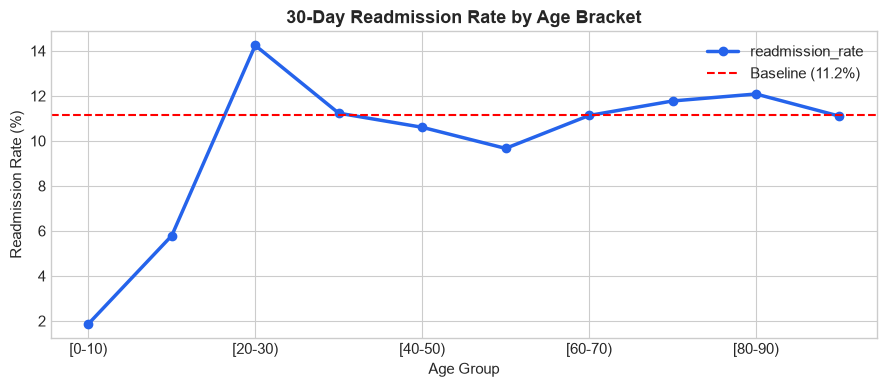

In [7]:
df_raw['readmit_30d'] = (df_raw['readmitted'] == '<30').astype(int)

age_summary = df_raw.groupby('age').agg(
    encounters=('encounter_id', 'count'),
    readmissions=('readmit_30d', 'sum')
)
age_summary['readmission_rate'] = (age_summary['readmissions'] / age_summary['encounters']) * 100

display(age_summary)

fig, ax = plt.subplots(figsize=(9, 4))
age_summary['readmission_rate'].plot(kind='line', marker='o', color='#2563eb', linewidth=2.5, ax=ax)
ax.set_title("30-Day Readmission Rate by Age Bracket", fontsize=13, fontweight='bold')
ax.set_ylabel("Readmission Rate (%)")
ax.set_xlabel("Age Group")
ax.axhline(base_rate, color='red', linestyle='--', label=f'Baseline ({base_rate:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()


### 6. Lab Tests: HbA1c and Serum Glucose
Inspecting `A1Cresult` and `max_glu_serum` values.

In [8]:
a1c_summary = df_raw.groupby('A1Cresult').agg(
    encounters=('encounter_id', 'count'),
    readmissions=('readmit_30d', 'sum')
)
a1c_summary['readmission_rate'] = (a1c_summary['readmissions'] / a1c_summary['encounters']) * 100
display(a1c_summary)


,encounters,readmissions,readmission_rate
A1Cresult,,,
>7,3812,383,10.047219
>8,8216,811,9.870983
None,84748,9681,11.423278
Norm,4990,482,9.659319


### 7. Key Findings & Next Steps for Phase 2
1. **Severe Imbalance:** Only ~11.16% of encounters are positive for 30-day readmission (`<30`).
2. **Missingness:** `weight` (~97% missing) and `payer_code` (~40% missing) must be dropped as planned (Rule C9).
3. **Deceased/Hospice Filtering:** Expired/hospice patients cannot be readmitted and will be dropped in Phase 2 (Rule C4).
4. **Grouped Split Required:** Over 17,000 patients have multiple stays. Train/Val/Test split MUST be grouped by `patient_nbr` to avoid leakage.